In [97]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks

for i in range(10):
    print(i)

df = pd.read_csv('ball_trajectory_data.csv')

# plt.figure(figsize=(10, 6))  # Optional: Adjust the size of the plot
# plt.plot(df.index, df['velocity'], label='Velocity')
# plt.xlabel('Frame (or Index)')
# plt.ylabel('Velocity')
# plt.title('Velocity Over Time')
# plt.legend()
# plt.grid(True)
# plt.show()

df['velocity_rolling_mean'] = df['mid_y'].rolling(window = 8, min_periods = 1, center = False).mean().round().astype(int)

peaks, _ = find_peaks(df['velocity_rolling_mean'], width=2, prominence=5)
print(f'original peaks: {peaks}')

troughs, _ = find_peaks(-df['velocity_rolling_mean'], prominence=5)
print(f'original troughs: {troughs}')

peaks = np.concatenate((peaks, troughs))
peaks = np.sort(peaks)

print(f'Joined peaks: {peaks}')

plt.figure(figsize=(24, 6))
plt.plot(df.index, df['velocity_rolling_mean'], label='Rolling Mean Velocity')

for peak in peaks:
    plt.axvspan(max(0, peak - 1), min(len(df), peak + 1), color='red', alpha=0.2, label='Peak Region' if peak == peaks[0] else '')

plt.scatter(peaks, df['velocity_rolling_mean'][peaks], color='red', marker='o', label='Peaks')

plt.xlabel('Frame')
plt.ylabel('Velocity')
plt.title('Rolling Mean Velocity with Highlighted Peak Regions')
plt.legend()
plt.grid(True)
plt.show()

num_peaks = len(peaks)
fig, axes = plt.subplots(num_peaks, 1, figsize=(10, 4 * num_peaks)) # Adjust figure size as needed

for i, peak in enumerate(peaks):
    ax = axes[i] if num_peaks > 1 else axes # Handle case of single peak
    start = max(0, peak - 10)
    end = min(len(df['velocity_rolling_mean']), peak + 11)
    part_to_plot = df['velocity_rolling_mean'][start:end]
    x_values = np.arange(start, end)

    ax.plot(x_values, part_to_plot, label=f'{part_to_plot.values}')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Velocity')
    ax.set_title(f'Rolling Mean Around Peak at Frame {peak}')
    ax.legend()

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()

0
1
2
3
4
5
6
7
8
9


KeyError: 'mid_y'

In [ ]:
import numpy as np
from collections import deque

# Given parameters
rho = 1.225 # Air density (kg/m^3)
Cd = 0.6    # Drag coefficient
A = 0.0034  # Cross-sectional area (m^2)
g = 9.81    # Acceleration due to gravity (m/s^2)
h = 1.0     # Initial height (m) - You'll need to provide this
t_total = 0.8  # Total time of flight (s) - You'll need to provide this

# Object properties (You'll need to provide an estimate for the mass)
m = 0.057  # Mass of the object (kg) - Example value, adjust as needed

def simulate_motion(v0, h, rho, Cd, A, m, g):
    dt = 0.001  # Time step
    t = 0
    y = h
    v = v0
    
    positions = []
    times = []
    
    # Upward motion
    while v > 0:
        v = v + dt * (-g - (rho * Cd * A * v**2) / (2 * m))
        y = y + v * dt
        t += dt
        positions.append(y)
        times.append(t)
    
    # At the top, velocity becomes 0
    v = 0
    
    # Downward motion
    while y > 0:
        v = v + dt * (-g + (rho * Cd * A * v**2) / (2 * m))
        y = y + v * dt
        t += dt
        positions.append(y)
        times.append(t)
    
    return t

# Initial guess for v0
v0_guess = 3.0

# Iterative search for v0
tolerance = 0.001
max_iterations = 1000
last_2_v0 = deque(maxlen=2)
for i in range(max_iterations):
    time_of_flight = simulate_motion(v0_guess, h, rho, Cd, A, m, g)
    print(f'iteration: {i}, time_of_flight: {time_of_flight}, vo_guess: {v0_guess}')

    if v0_guess in last_2_v0:
        v0_guess = sum(last_2_v0) / len(last_2_v0)
        break
    else:
        last_2_v0.append(v0_guess)

    if abs(time_of_flight - t_total) < tolerance:
        break
    elif time_of_flight < t_total:
        v0_guess += 0.1  # Increase v0
    else:
        v0_guess -= 0.1  # Decrease v0

print(f"Initial velocity: {v0_guess:.2f} m/s")



iteration: 0, time_of_flight: 0.8510000000000006, vo_guess: 3.0
iteration: 1, time_of_flight: 0.8350000000000006, vo_guess: 2.9
iteration: 2, time_of_flight: 0.8200000000000006, vo_guess: 2.8
iteration: 3, time_of_flight: 0.8050000000000006, vo_guess: 2.6999999999999997
iteration: 4, time_of_flight: 0.7890000000000006, vo_guess: 2.5999999999999996
iteration: 5, time_of_flight: 0.8050000000000006, vo_guess: 2.6999999999999997
Initial velocity: 2.65 m/s


time: [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8 ], positions: [ 1.    1.11  1.19  1.25  1.28  1.29  1.28  1.24  1.17  1.08  0.97  0.83
  0.67  0.48  0.27  0.04 -0.21]
Height at 1.00 s: -0.21 m


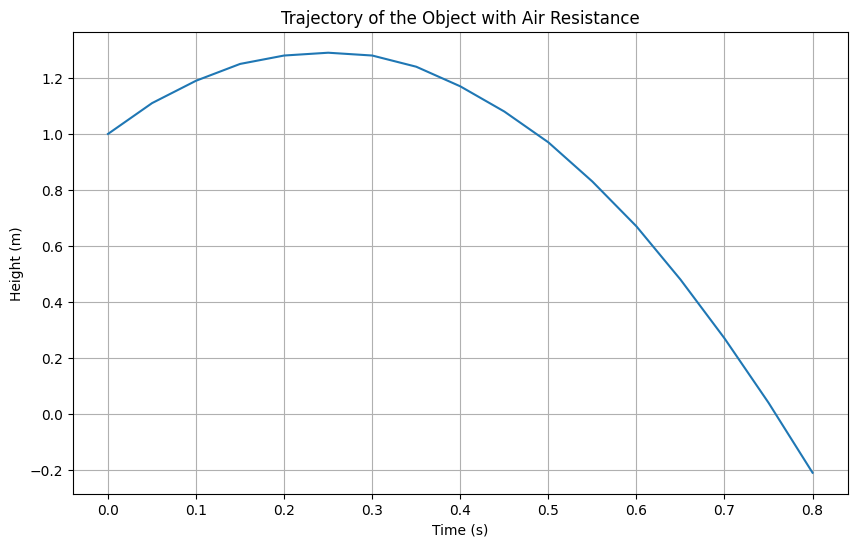

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Given parameters (use the v0 you found previously)
rho = 1.225  # Air density (kg/m^3)
Cd = 0.6    # Drag coefficient
A = 0.0034   # Cross-sectional area (m^2)
g = 9.81    # Acceleration due to gravity (m/s^2)
h_initial = 1.0  # Starting from the ground
v0 = 2.65      # Replace with the initial velocity you calculated
m = 0.057        # Mass of the object (kg) - Ensure this is consistent

def simulate_trajectory(v0, h_initial, rho, Cd, A, m, g, t_max=5.0, dt=0.05):
    """Simulates the trajectory of the object with air resistance."""
    t = 0
    y = h_initial
    v = v0
    
    times = [t]
    positions = [y]
    velocities = [v]
    
    # Upward motion
    while v > 0 or y > 0:  # Continue until it returns to or below initial height
        if v >= 0:
            v = v + dt * (-g - (rho * Cd * A * v**2) / (2 * m))
        else:
            v = v + dt * (-g + (rho * Cd * A * v**2) / (2 * m))
            
        y = y + v * dt
        t += dt
        
        times.append(t)
        positions.append(round(y, 2))
        velocities.append(v)
        
        if t > t_max: # Safety break to prevent infinite loops
            break
            
    return np.array(times), np.array(positions), np.array(velocities)

# Simulate the trajectory
times, positions, velocities = simulate_trajectory(v0, h_initial, rho, Cd, A, m, g)
print(f"time: {times}, positions: {positions}")
# You can now find the distance at any time from the 'positions' and 'times' arrays

# Example: Find the height at a specific time (e.g., 1 second)
target_time = 1.0
closest_index = np.argmin(np.abs(times - target_time))
height_at_target_time = positions[closest_index]
print(f"Height at {target_time:.2f} s: {height_at_target_time:.2f} m")

# You can also plot the trajectory
plt.figure(figsize=(10, 6))
plt.plot(times, positions)
plt.xlabel("Time (s)")
plt.ylabel("Height (m)")
plt.title("Trajectory of the Object with Air Resistance")
plt.grid(True)
plt.show()